# Medical Insurance Cost Prediction

## Linear Regression Project

This project builds a **Linear Regression** model to predict medical insurance charges using customer attributes such as age, sex, BMI, number of children, smoking status, and region.

### Project objectives

- Explore and understand the insurance dataset.
- Visualize relationships between the features and the target variable (`charges`).
- Convert categorical variables into numerical values using `LabelEncoder`.
- Split the data into 80% training data and 20% testing data.
- Train and test a Linear Regression model.
- Evaluate the model using MAE, MSE, RMSE, and R².

> **Target variable:** `charges`  
> **Model:** Linear Regression  
> **Train/test split:** 80% / 20%  
> **Random state:** 42


## 1. Import Libraries

The project uses NumPy and Pandas for data handling, Matplotlib and Seaborn for visualization, and Scikit-learn for preprocessing, model training, and evaluation.


In [ ]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import gaussian_kde
from matplotlib.colors import LinearSegmentedColormap
from IPython.display import display, Markdown

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

# ------------------------ Visual Theme ------------------------
PURPLE = "#AB49A2"
DARK_PURPLE = "#6F2869"
LIGHT_PURPLE = "#D9A5D3"
BACKGROUND = "#F5F5F5"
TEXT_COLOR = "#111111"
GRID_COLOR = "#222222"

sns.set_theme(style="white")

plt.rcParams.update({
    "figure.facecolor": BACKGROUND,
    "axes.facecolor": BACKGROUND,
    "axes.edgecolor": TEXT_COLOR,
    "axes.labelcolor": TEXT_COLOR,
    "xtick.color": TEXT_COLOR,
    "ytick.color": TEXT_COLOR,
    "text.color": TEXT_COLOR,
    "font.family": "monospace",
    "axes.titleweight": "bold",
    "axes.titlesize": 16,
    "axes.labelsize": 11,
})


def style_axis(ax, title, xlabel="", ylabel="", grid_axis="y", annotation=None):
    """Apply the project's visual style to a Matplotlib axis."""
    ax.figure.set_facecolor(BACKGROUND)
    ax.set_facecolor(BACKGROUND)

    sns.despine(ax=ax)

    ax.set_title(
        title,
        loc="right",
        pad=12,
        fontsize=16,
        fontweight="bold",
        fontfamily="monospace"
    )
    ax.set_xlabel(xlabel, fontfamily="monospace")
    ax.set_ylabel(ylabel, fontfamily="monospace")

    ax.set_axisbelow(True)
    ax.grid(
        True,
        which="both",
        axis=grid_axis,
        color=GRID_COLOR,
        linestyle=":",
        dashes=(2, 8),
        alpha=0.45
    )

    if annotation:
        ax.text(
            0.58,
            0.84,
            annotation,
            transform=ax.transAxes,
            fontsize=11,
            fontfamily="monospace",
            va="top"
        )


def filled_kde(ax, values, padding_ratio=0.08):
    """Draw a smooth filled KDE with a black outline."""
    values = np.asarray(values, dtype=float)
    value_range = values.max() - values.min()
    padding = value_range * padding_ratio

    x_values = np.linspace(
        values.min() - padding,
        values.max() + padding,
        500
    )

    density = gaussian_kde(values)(x_values)

    ax.fill_between(
        x_values,
        density,
        color=PURPLE,
        alpha=0.80
    )
    ax.plot(
        x_values,
        density,
        color="black",
        linewidth=3
    )

    return x_values, density


## 2. Load the Dataset

The code below searches for the dataset in common project locations. This makes the notebook portable and suitable for GitHub instead of depending on one computer's absolute file path.

Recommended GitHub structure:

```text
medical-insurance-prediction/
├── data/
│   └── insurance.csv
└── Medical_Insurance_Prediction_Enhanced.ipynb
```


In [ ]:
candidate_paths = [
    Path("data/insurance.csv"),
    Path("insurance.csv"),
    Path("../data/insurance.csv"),
]

data_path = next((path for path in candidate_paths if path.exists()), None)

if data_path is None:
    raise FileNotFoundError(
        "insurance.csv was not found. Place it beside the notebook or inside a data folder."
    )

df = pd.read_csv(data_path)

print(f"Dataset loaded from: {data_path.resolve()}")
print(f"Dataset shape: {df.shape}")
df.head()


Dataset loaded from: /mnt/data/insurance.csv
Dataset shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 3. Dataset Overview

The first stage of EDA uses `head()`, `info()`, and `describe()` to inspect the dataset structure, data types, and summary statistics.


### 3.1 First Five Rows

In [ ]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


### 3.2 Dataset Information

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


### 3.3 Descriptive Statistics

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


### 3.4 Data Quality Checks

Before modeling, the dataset is checked for missing values and duplicate rows.


In [ ]:
print("Missing values per column:")
display(df.isnull().sum().to_frame(name="Missing Values"))

duplicate_count = df.duplicated().sum()
print(f"Duplicate rows: {duplicate_count}")


Missing values per column:


,Missing Values
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


Duplicate rows: 1


### 3.5 Remove Duplicate Rows

The dataset contains one duplicated observation. It is removed to avoid giving that record unnecessary extra influence during model training.


In [ ]:
rows_before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
rows_after = len(df)

print(f"Rows before removing duplicates: {rows_before}")
print(f"Rows after removing duplicates:  {rows_after}")
print(f"Rows removed: {rows_before - rows_after}")


Rows before removing duplicates: 1338
Rows after removing duplicates:  1337
Rows removed: 1


## 4. Exploratory Data Analysis

### 4.1 Distribution of Medical Charges

A smooth density curve is used to visualize the distribution of the target variable. The filled purple design, dark outline, dotted grid, and light background are used consistently throughout the notebook.


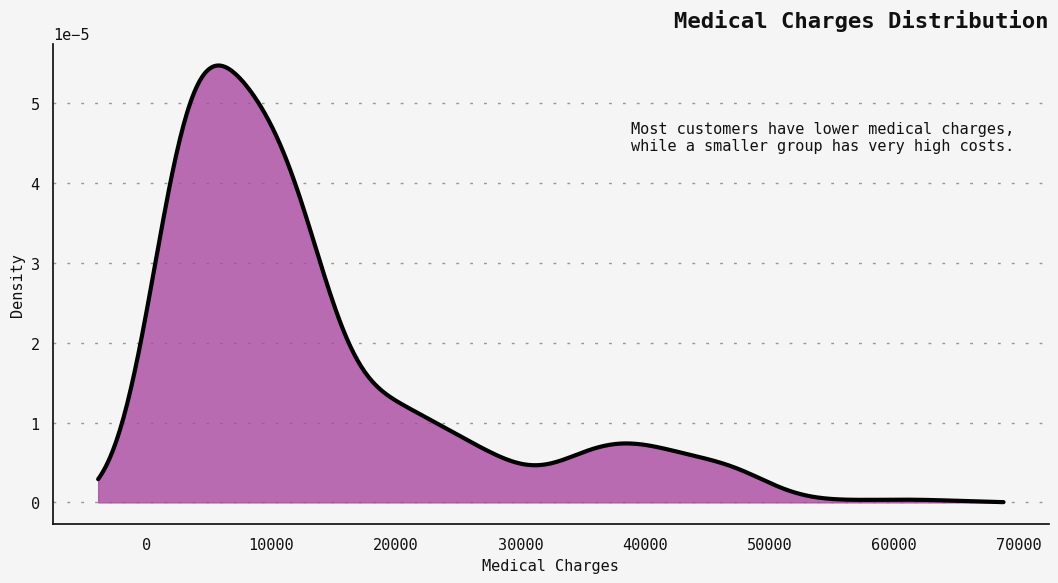

In [ ]:
fig, ax = plt.subplots(figsize=(11, 6))

filled_kde(ax, df["charges"])

style_axis(
    ax,
    title="Medical Charges Distribution",
    xlabel="Medical Charges",
    ylabel="Density",
    annotation=(
        "Most customers have lower medical charges,\n"
        "while a smaller group has very high costs."
    )
)

plt.tight_layout()
plt.show()


**Observation:** The distribution of `charges` is positively skewed. Most observations are concentrated in the lower-cost range, while a smaller number of customers have substantially higher medical charges.


### 4.2 Categorical Features vs. Medical Charges

Box plots are appropriate because `sex`, `smoker`, and `region` are categorical variables, while `charges` is numerical. They show the median, spread, and potential outliers for each category.


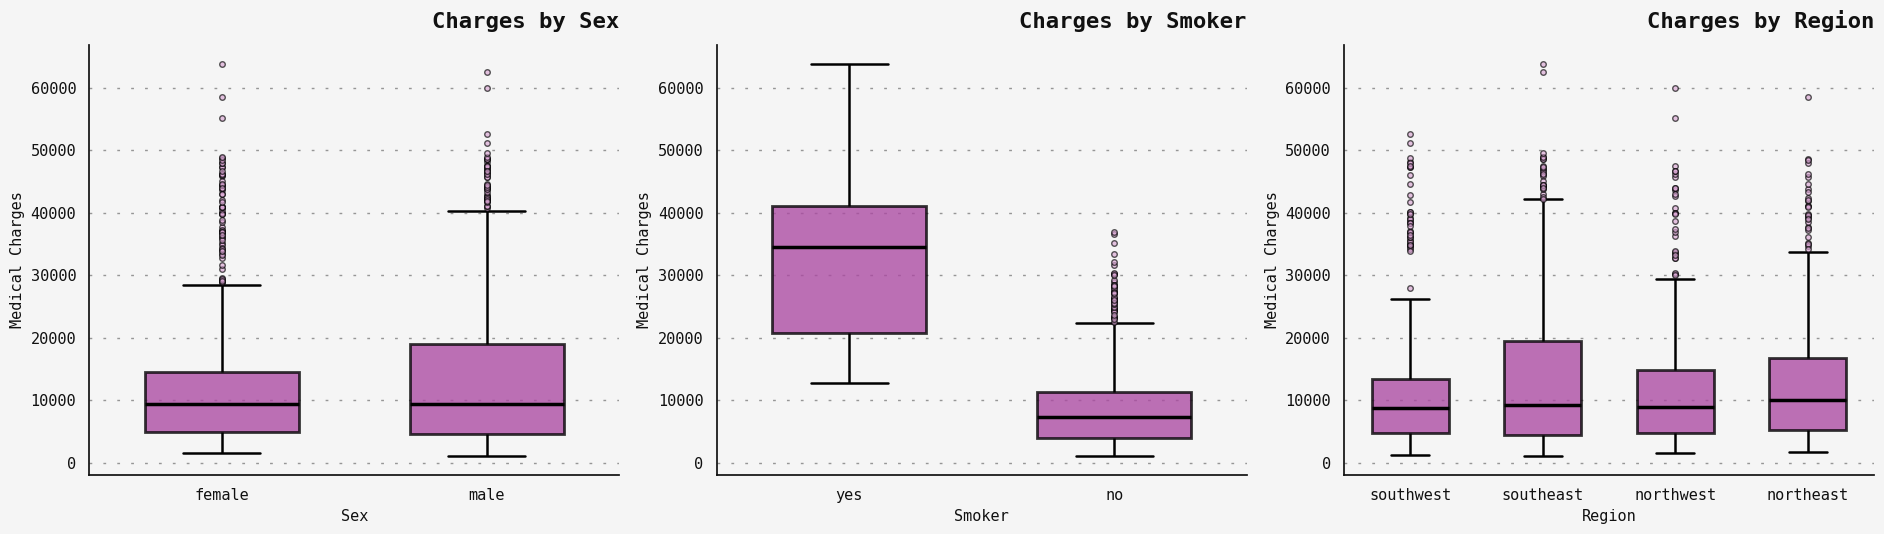

In [ ]:
categorical_features = ["sex", "smoker", "region"]

fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))
fig.set_facecolor(BACKGROUND)

for ax, feature in zip(axes, categorical_features):
    sns.boxplot(
        data=df,
        x=feature,
        y="charges",
        ax=ax,
        width=0.58,
        boxprops={
            "facecolor": PURPLE,
            "alpha": 0.78,
            "edgecolor": "black",
            "linewidth": 2
        },
        medianprops={
            "color": "black",
            "linewidth": 2.5
        },
        whiskerprops={
            "color": "black",
            "linewidth": 1.8
        },
        capprops={
            "color": "black",
            "linewidth": 1.8
        },
        flierprops={
            "marker": "o",
            "markerfacecolor": LIGHT_PURPLE,
            "markeredgecolor": "black",
            "markersize": 4,
            "alpha": 0.65
        }
    )

    style_axis(
        ax,
        title=f"Charges by {feature.title()}",
        xlabel=feature.title(),
        ylabel="Medical Charges",
        grid_axis="y"
    )

plt.tight_layout()
plt.show()


**Observations:**

- **Smoking status** shows the clearest difference: smokers generally have substantially higher medical charges.
- The distributions for **male and female** customers overlap considerably.
- Medical charges vary across **regions**, but the regional differences are much smaller than the difference between smokers and non-smokers.


### 4.3 Pairwise Relationships

The pair plot displays relationships among the numerical features and the target. Smoking status is used as the color grouping because it appears to be highly relevant to medical charges.


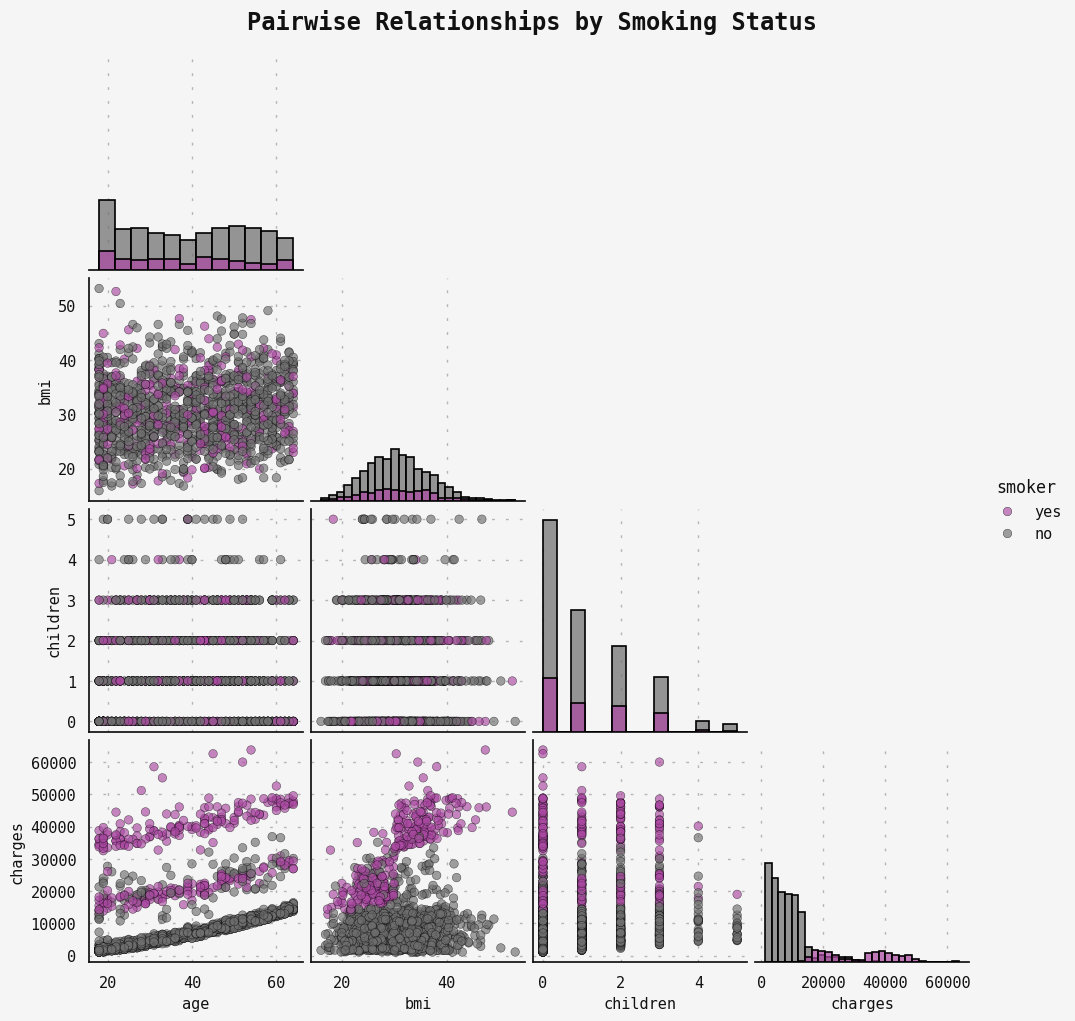

In [ ]:
pairplot_features = ["age", "bmi", "children", "charges", "smoker"]

pair_grid = sns.pairplot(
    data=df[pairplot_features],
    vars=["age", "bmi", "children", "charges"],
    hue="smoker",
    diag_kind="hist",
    corner=True,
    height=2.5,
    palette={
        "yes": PURPLE,
        "no": "#6F6F6F"
    },
    plot_kws={
        "alpha": 0.65,
        "s": 38,
        "edgecolor": "black",
        "linewidth": 0.35
    },
    diag_kws={
        "alpha": 0.72,
        "edgecolor": "black",
        "linewidth": 1.2
    }
)

pair_grid.fig.set_facecolor(BACKGROUND)
pair_grid.fig.suptitle(
    "Pairwise Relationships by Smoking Status",
    y=1.02,
    fontsize=17,
    fontweight="bold",
    fontfamily="monospace"
)

for row in pair_grid.axes:
    for ax in row:
        if ax is not None:
            ax.set_facecolor(BACKGROUND)
            ax.set_axisbelow(True)
            ax.grid(
                True,
                linestyle=":",
                dashes=(2, 8),
                color=GRID_COLOR,
                alpha=0.30
            )

plt.show()


**Observation:** Charges tend to increase with age and BMI. The separation between smokers and non-smokers is especially visible, indicating that smoking status is likely to be one of the model's strongest predictors.


### 4.4 Outlier Inspection

A box plot is used to identify unusually high medical charges. These observations are retained because high medical costs can be legitimate cases and are part of the prediction problem. Removing them without a strong domain-based reason could bias the model.


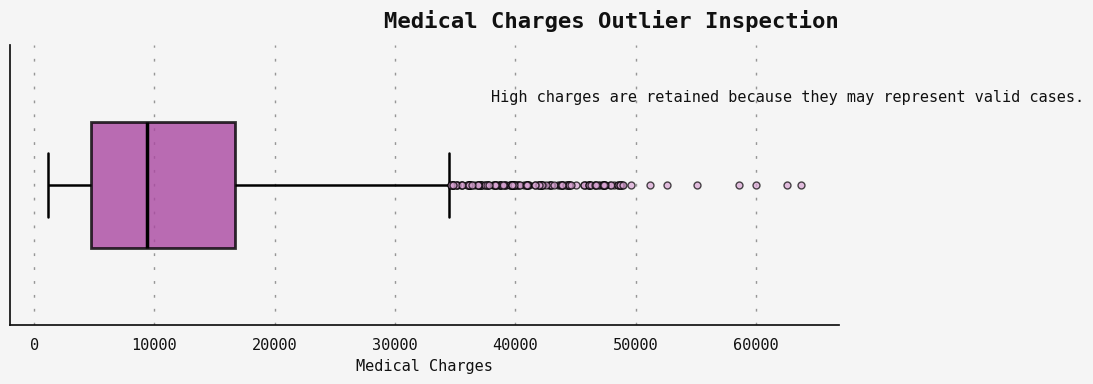

IQR upper bound: 34,524.78
Number of observations above the upper IQR bound: 139


In [ ]:
fig, ax = plt.subplots(figsize=(11, 4))

sns.boxplot(
    data=df,
    x="charges",
    ax=ax,
    width=0.45,
    boxprops={
        "facecolor": PURPLE,
        "alpha": 0.80,
        "edgecolor": "black",
        "linewidth": 2
    },
    medianprops={
        "color": "black",
        "linewidth": 2.5
    },
    whiskerprops={
        "color": "black",
        "linewidth": 1.8
    },
    capprops={
        "color": "black",
        "linewidth": 1.8
    },
    flierprops={
        "marker": "o",
        "markerfacecolor": LIGHT_PURPLE,
        "markeredgecolor": "black",
        "markersize": 5,
        "alpha": 0.70
    }
)

style_axis(
    ax,
    title="Medical Charges Outlier Inspection",
    xlabel="Medical Charges",
    ylabel="",
    grid_axis="x",
    annotation="High charges are retained because they may represent valid cases."
)

q1 = df["charges"].quantile(0.25)
q3 = df["charges"].quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr
outlier_count = (df["charges"] > upper_bound).sum()

plt.tight_layout()
plt.show()

print(f"IQR upper bound: {upper_bound:,.2f}")
print(f"Number of observations above the upper IQR bound: {outlier_count}")


## 5. Encode Categorical Features

Linear Regression requires numerical input. `LabelEncoder` is used because it is explicitly required by the project instructions.

The original DataFrame is preserved for readable visualizations, while an encoded copy is created for correlation analysis and modeling.

> **Methodology note:** Label encoding is suitable for the assignment. In a production project, one-hot encoding would usually be preferred for `region` because its categories do not have a natural order.


In [ ]:
categorical_columns = ["sex", "smoker", "region"]
df_encoded = df.copy()
encoding_mappings = {}

for column in categorical_columns:
    encoder = LabelEncoder()
    df_encoded[column] = encoder.fit_transform(df_encoded[column])
    encoding_mappings[column] = {
        category: int(code)
        for category, code in zip(encoder.classes_, encoder.transform(encoder.classes_))
    }

print("Encoding mappings:")
for column, mapping in encoding_mappings.items():
    print(f"{column}: {mapping}")

df_encoded.head()


Encoding mappings:
sex: {'female': 0, 'male': 1}
smoker: {'no': 0, 'yes': 1}
region: {'northeast': 0, 'northwest': 1, 'southeast': 2, 'southwest': 3}


,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


### 5.1 Correlation Heatmap

The heatmap shows the linear relationships between the encoded features and the target variable.


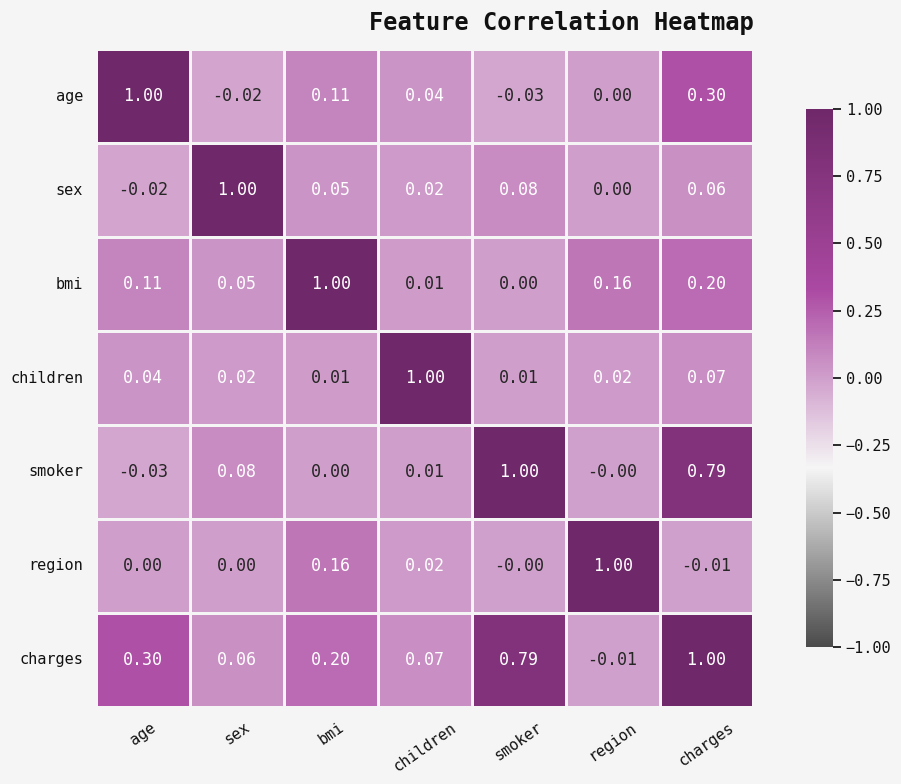

Correlation with medical charges:


,Correlation with Charges
charges,1.000000
smoker,0.787234
age,0.298308
bmi,0.198401
children,0.067389
sex,0.058044
region,-0.006547


In [ ]:
correlation_matrix = df_encoded.corr(numeric_only=True)

purple_cmap = LinearSegmentedColormap.from_list(
    "purple_correlation",
    ["#4B4B4B", "#F5F5F5", PURPLE, DARK_PURPLE]
)

fig, ax = plt.subplots(figsize=(11, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap=purple_cmap,
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=1,
    linecolor=BACKGROUND,
    square=True,
    cbar_kws={"shrink": 0.82},
    ax=ax
)

ax.set_title(
    "Feature Correlation Heatmap",
    loc="right",
    pad=14,
    fontsize=17,
    fontweight="bold",
    fontfamily="monospace"
)
ax.tick_params(axis="x", rotation=35)
ax.tick_params(axis="y", rotation=0)
fig.set_facecolor(BACKGROUND)

plt.tight_layout()
plt.show()

print("Correlation with medical charges:")
display(
    correlation_matrix["charges"]
    .sort_values(ascending=False)
    .to_frame(name="Correlation with Charges")
)


**Observation:** Smoking status has the strongest positive correlation with medical charges. Age and BMI also have positive relationships with the target, while sex, number of children, and region show weaker linear correlations.


## 6. Define Features and Target

All columns except `charges` are used as independent variables (`X`). The `charges` column is the dependent target variable (`y`).


In [ ]:
X = df_encoded.drop(columns="charges")
y = df_encoded["charges"]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print("\nFeatures used by the model:")
print(list(X.columns))


X shape: (1337, 6)
y shape: (1337,)

Features used by the model:
['age', 'sex', 'bmi', 'children', 'smoker', 'region']


## 7. Training and Testing Split

The dataset is divided into:

- **Training data:** 80%
- **Testing data:** 20%
- **Random state:** 42

The fixed random state makes the split reproducible.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(f"Training feature shape: {X_train.shape}")
print(f"Testing feature shape:  {X_test.shape}")
print(f"Training target shape:  {y_train.shape}")
print(f"Testing target shape:   {y_test.shape}")


Training feature shape: (1069, 6)
Testing feature shape:  (268, 6)
Training target shape:  (1069,)
Testing target shape:   (268,)


## 8. Model Training

A Linear Regression model is created and trained using the training data.


In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")


Linear Regression model trained successfully.


## 9. Model Testing

### 9.1 Intercept and Coefficients

The intercept is the predicted baseline value when all encoded inputs equal zero. Each coefficient estimates how much the predicted charge changes when its corresponding feature increases by one unit, while the other features remain constant.


In [ ]:
print(f"Intercept: {model.intercept_:,.4f}")

coefficient_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficient_df["Absolute Coefficient"] = coefficient_df["Coefficient"].abs()
coefficient_df = coefficient_df.sort_values(
    by="Absolute Coefficient",
    ascending=False
).reset_index(drop=True)

display(coefficient_df)


Intercept: -11,047.6866


,Feature,Coefficient,Absolute Coefficient
0,smoker,23052.152752,23052.152752
1,children,534.120877,534.120877
2,bmi,312.609045,312.609045
3,age,248.764071,248.764071
4,region,-237.625147,237.625147
5,sex,-99.695394,99.695394


### 9.2 Predictions and Real Values

The trained model predicts charges for the unseen testing data. The first ten predictions are shown beside their true values for readability.


In [ ]:
predictions = model.predict(X_test)
real_values = y_test.to_numpy()
residuals = real_values - predictions

print("First 10 predictions:")
print(np.round(predictions[:10], 2))

print("\nFirst 10 real values:")
print(np.round(real_values[:10], 2))

comparison_df = pd.DataFrame({
    "Real Values": real_values,
    "Predictions": predictions,
    "Residuals": residuals
})

comparison_df.head(10)


First 10 predictions:
[ 8080.45  5592.87 14378.3  31731.82  9158.36 13361.01 30257.66  1308.65
 10849.43 11375.55]

First 10 real values:
[ 8688.86  5708.87 11436.74 38746.36  4463.21  9304.7  38511.63  2150.47
  7345.73 10264.44]


,Real Values,Predictions,Residuals
0,8688.85885,8080.450186,608.408664
1,5708.86700,5592.871120,115.995880
2,11436.73815,14378.298655,-2941.560505
3,38746.35510,31731.819541,7014.535559
4,4463.20510,9158.356944,-4695.151844
5,9304.70190,13361.014269,-4056.312369
6,38511.62830,30257.655258,8253.973042
7,2150.46900,1308.647356,841.821644
8,7345.72660,10849.425445,-3503.698845
9,10264.44210,11375.548519,-1111.106419


### 9.3 Predicted vs. Actual Charges

A strong model should place points close to the diagonal reference line, where predicted values equal actual values.


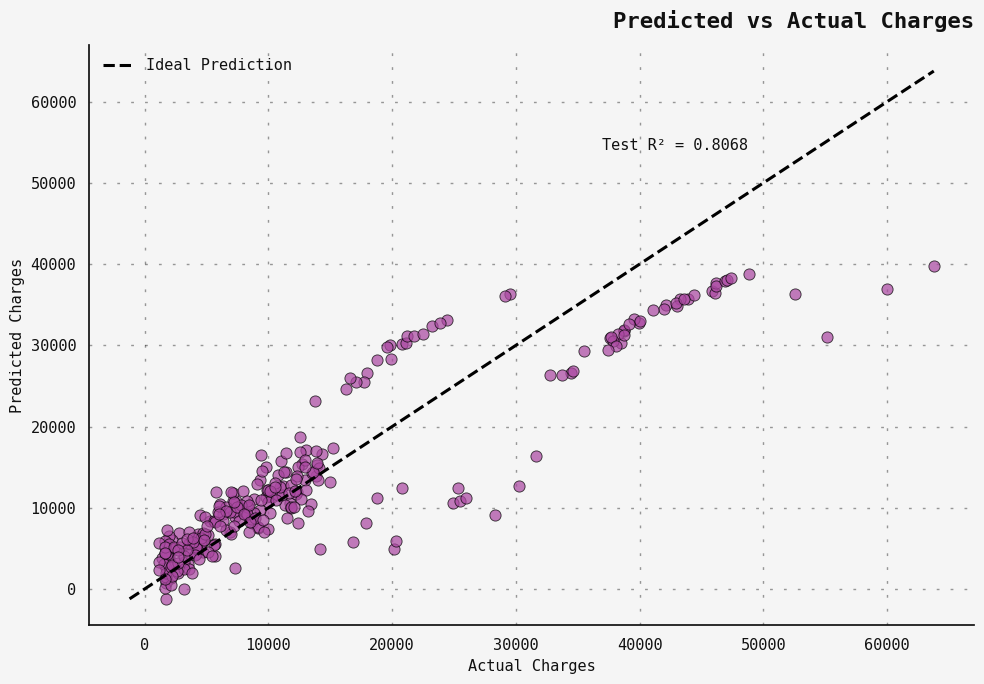

In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(
    real_values,
    predictions,
    s=65,
    color=PURPLE,
    alpha=0.72,
    edgecolor="black",
    linewidth=0.65
)

minimum_value = min(real_values.min(), predictions.min())
maximum_value = max(real_values.max(), predictions.max())

ax.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    color="black",
    linestyle="--",
    linewidth=2.2,
    label="Ideal Prediction"
)

style_axis(
    ax,
    title="Predicted vs Actual Charges",
    xlabel="Actual Charges",
    ylabel="Predicted Charges",
    grid_axis="both",
    annotation=f"Test R² = {r2_score(y_test, predictions):.4f}"
)

ax.legend(frameon=False, prop={"family": "monospace"})
plt.tight_layout()
plt.show()


### 9.4 Residual Histogram

Residuals are calculated as:

`Residual = Actual Value - Predicted Value`

A residual distribution centered near zero is desirable. Large positive or negative residuals indicate cases where the model underestimates or overestimates the actual charge.


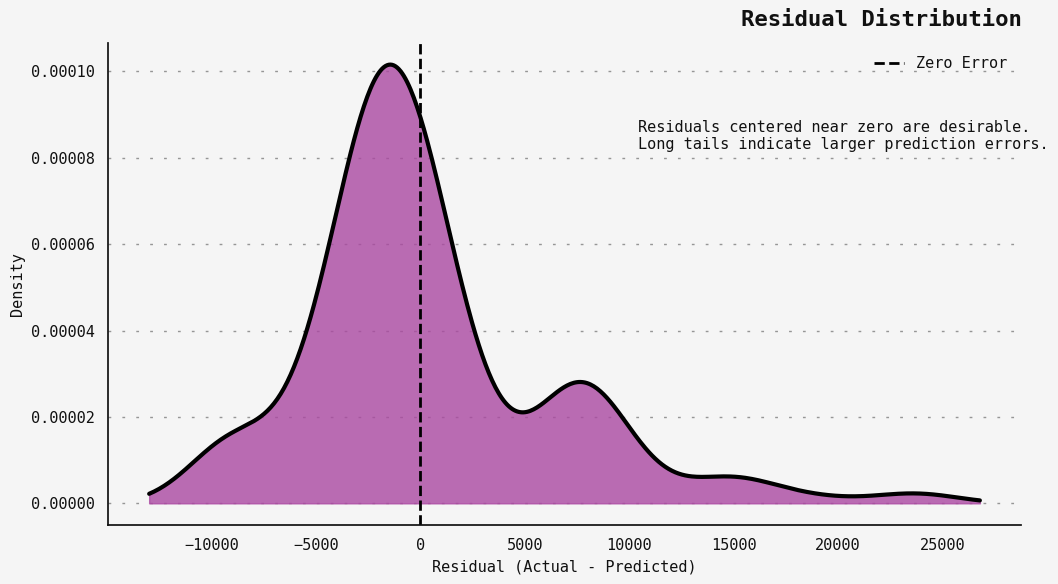

In [ ]:
fig, ax = plt.subplots(figsize=(11, 6))

filled_kde(ax, residuals)

ax.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=2,
    label="Zero Error"
)

style_axis(
    ax,
    title="Residual Distribution",
    xlabel="Residual (Actual - Predicted)",
    ylabel="Density",
    annotation=(
        "Residuals centered near zero are desirable.\n"
        "Long tails indicate larger prediction errors."
    )
)

ax.legend(frameon=False, prop={"family": "monospace"})
plt.tight_layout()
plt.show()


## 10. Model Evaluation

The model is evaluated using four regression metrics:

- **MAE:** Average absolute prediction error.
- **MSE:** Average squared prediction error; it penalizes large errors strongly.
- **RMSE:** Square root of MSE, expressed in the same unit as `charges`.
- **R²:** Proportion of variance in medical charges explained by the model.


In [ ]:
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

evaluation_df = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R²"],
    "Value": [mae, mse, rmse, r2]
})

display(evaluation_df)

print(f"MAE:  {mae:,.2f}")
print(f"MSE:  {mse:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R²:   {r2:.4f}")


,Metric,Value
0,MAE,4.182353e+03
1,MSE,3.549310e+07
2,RMSE,5.957609e+03
3,R²,8.068466e-01


MAE:  4,182.35
MSE:  35,493,102.61
RMSE: 5,957.61
R²:   0.8068


## 11. Conclusion

The following conclusion is generated from the final model results so that it remains consistent with the executed notebook.


In [ ]:
display(Markdown(f"""
The Linear Regression model achieved an **R² score of {r2:.4f}**, meaning that it explains approximately **{r2 * 100:.2f}%** of the variation in medical insurance charges in the test data.

Its **MAE is {mae:,.2f}**, so the predictions differ from the true charges by approximately that amount on average. The **RMSE is {rmse:,.2f}**, which is higher than the MAE because it gives greater weight to large prediction errors.

### Main findings

- Smoking status is the strongest predictor of medical charges.
- Age and BMI also contribute positively to predicted insurance costs.
- The model performs well as an interpretable baseline.
- Some high-cost observations remain difficult for a simple linear model to predict.

### Possible future improvements

- Use one-hot encoding for nominal features such as `region`.
- Test a logarithmic transformation of the skewed `charges` target.
- Add interaction features such as `bmi × smoker`.
- Compare Linear Regression with Random Forest or Gradient Boosting.
"""))



The Linear Regression model achieved an **R² score of 0.8068**, meaning that it explains approximately **80.68%** of the variation in medical insurance charges in the test data.

Its **MAE is 4,182.35**, so the predictions differ from the true charges by approximately that amount on average. The **RMSE is 5,957.61**, which is higher than the MAE because it gives greater weight to large prediction errors.

### Main findings

- Smoking status is the strongest predictor of medical charges.
- Age and BMI also contribute positively to predicted insurance costs.
- The model performs well as an interpretable baseline.
- Some high-cost observations remain difficult for a simple linear model to predict.

### Possible future improvements

- Use one-hot encoding for nominal features such as `region`.
- Test a logarithmic transformation of the skewed `charges` target.
- Add interaction features such as `bmi × smoker`.
- Compare Linear Regression with Random Forest or Gradient Boosting.
